In [ ]:
!pip install datasets -q

In [ ]:
import os
from google.colab import userdata
from huggingface_hub import login
from datasets import load_dataset, Dataset, DatasetDict
import matplotlib.pyplot as plt
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

Loading data from huggingFace

In [ ]:
dataset = load_dataset("ShravSiddhpura/cybersec-slopsquatting-crag" , split="train")
df = pd.DataFrame(dataset)



df['full_text'] = df['prompt'] + " " + df['answer']
print(f"Successfully loaded {len(df)} rows.")


README.md:   0%|          | 0.00/354 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/472k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/904 [00:00<?, ? examples/s]

Successfully loaded 904 rows.


In [ ]:
# To display the first 10 rows of your dataframe 'df':
display(df.head(4))

,prompt,answer,label,full_text
0,What is the most effective way to validate and...,"To handle this securely, you can use the pyasn...",0,What is the most effective way to validate and...
1,How can I implement a secure way to encrypt an...,To ensure secure data encryption and decryptio...,1,How can I implement a secure way to encrypt an...
2,What are some best practices for secure error ...,Secure error handling is crucial for any Pytho...,1,What are some best practices for secure error ...
3,How can I use the ` hashlib` library in Python...,"To handle this securely, you can use the 'pyth...",0,How can I use the ` hashlib` library in Python...


# Train-Test Split & TF-IDF Vectorization

Explanation: We separate our data, reserving exactly 200 rows for the strict validation threshold required by your architecture. Then, we fit the TfidfVectorizer to learn the vocabulary of the training set and transform the raw text into mathematical vectors that algorithms can understand.

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(
    df['full_text'],df['label'],
    test_size=200,
    random_state=42,
    stratify=df['label']
)
print(f"Training on {len(x_train)} rows")
print(f"Evaluating on {len(x_test)} rows")

Training on 704 rows
Evaluating on 200 rows


In [ ]:
#creating vectors
#Limiting to 5000 features and removing unecessary words (like 'and' , 'the' , etc)
vectorizer=TfidfVectorizer(max_features=5000,stop_words='english')

X_train_vec=vectorizer.fit_transform(x_train)
X_test_vec=vectorizer.transform(x_test)


# Defining our Evaluaiton function



# > Simple function



In [ ]:
def evaluation(model , X_test_features , y_actual , model_name):
    print(f"\n{'='*40}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*40}")

    # generate prediction
    y_pred= model.predict(X_test_features)

    #print accuracy and Classification Report
    print(f"Accuracy: {accuracy_score(y_actual, y_pred):.4f}\n")
    print(classification_report(y_actual, y_pred, target_names=['Grounded (0)', 'Hallucinated (1)']))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_actual, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                  xticklabels=['Grounded', 'Hallucinated'],
                  yticklabels=['Grounded', 'Hallucinated'])
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()



# > Complex Function



In [ ]:
from itertools import accumulate
import numpy as np

def evaluate_model(model, X_test_features, y_actual, model_name):
    print(f"\n{'='*40}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*40}")

    # Generate predictions
    y_pred = model.predict(X_test_features)
    y_actual_array = np.array(y_actual)

    # Print Accuracy and Classification Report
    print(f"Accuracy: {accuracy_score(y_actual, y_pred):.4f}\n")
    print(classification_report(y_actual, y_pred, target_names=['Grounded (0)', 'Hallucinated (1)']))

    # --- CALCULATE ERROR TREND ---
    # 1 if prediction is wrong, 0 if prediction is right
    incorrect_predictions = (y_pred != y_actual_array).astype(int)

    # Running sum of errors (using the accumulate logic from your instructor)
    running_errors = list(accumulate(incorrect_predictions))
    x_axis = list(range(1, len(y_actual_array) + 1))

    # Calculate the running error rate (Total Errors / Total Processed so far)
    cumulative_error_rate = [err / i for err, i in zip(running_errors, x_axis)]

    # --- PLOTTING ---
    # Create a 1x2 grid to show both charts side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Plot Confusion Matrix (Left side)
    cm = confusion_matrix(y_actual_array, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Grounded', 'Hallucinated'],
                yticklabels=['Grounded', 'Hallucinated'], ax=axes[0])
    axes[0].set_title(f"Confusion Matrix: {model_name}")
    axes[0].set_ylabel('Actual Label')
    axes[0].set_xlabel('Predicted Label')

    # 2. Plot Cumulative Error Trend (Right side)
    axes[1].plot(x_axis, cumulative_error_rate, color='firebrick', linewidth=2)
    axes[1].set_title(f"Cumulative Error Rate Trend: {model_name}")
    axes[1].set_xlabel("Number of Datapoints Evaluated")
    axes[1].set_ylabel("Running Error Rate (Lower is Better)")
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # Ensure the y-axis scales nicely based on the error data
    max_err = max(cumulative_error_rate)
    axes[1].set_ylim(0, max(0.5, max_err * 1.2)) # Cap at 0.5 unless the model is really bad

    plt.tight_layout()
    plt.show()

# LOGISTIC REGRESSION

Logistic Regression is the industry-standard baseline for binary text classification. It is incredibly fast and highly interpretable. Pay close attention to the "Recall" for the Hallucinated class when this runs.

In [ ]:
#Train and evaluate Logistic Regression

log_reg = LogisticRegression(random_state=42,max_iter=1000)
log_reg.fit(X_train_vec, y_train)


LogisticRegression(max_iter=1000, random_state=42)


Evaluating: Logistic Regression
Accuracy: 1.0000

                  precision    recall  f1-score   support

    Grounded (0)       1.00      1.00      1.00       108
Hallucinated (1)       1.00      1.00      1.00        92

        accuracy                           1.00       200
       macro avg       1.00      1.00      1.00       200
    weighted avg       1.00      1.00      1.00       200



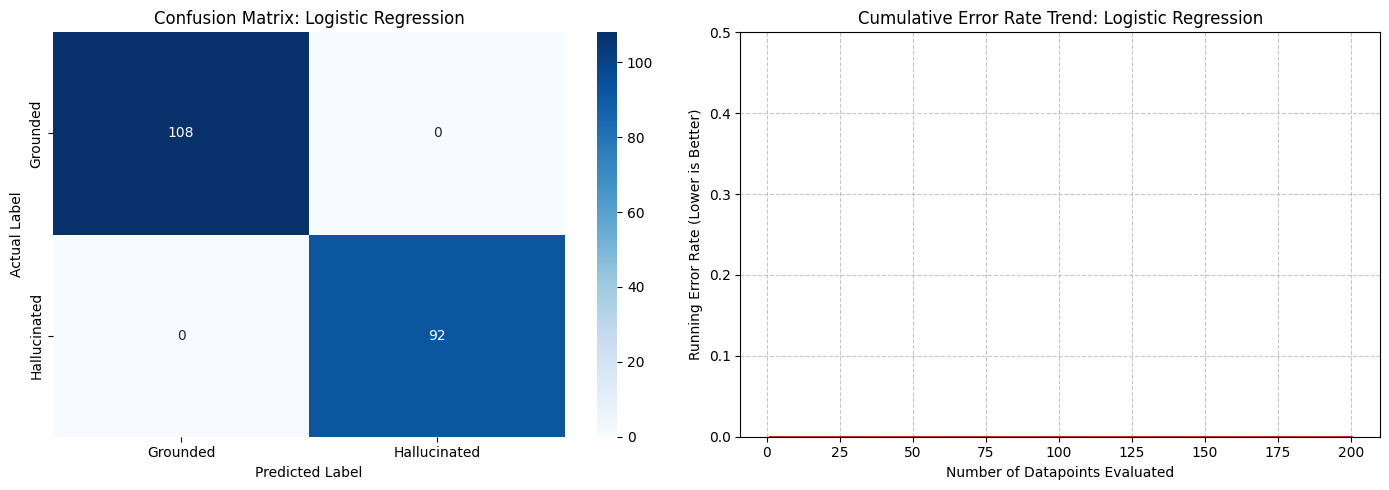

In [ ]:
evaluate_model(log_reg,X_test_vec,y_test , "Logistic Regression")


Evaluating: Random Forest
Accuracy: 1.0000

                  precision    recall  f1-score   support

    Grounded (0)       1.00      1.00      1.00       108
Hallucinated (1)       1.00      1.00      1.00        92

        accuracy                           1.00       200
       macro avg       1.00      1.00      1.00       200
    weighted avg       1.00      1.00      1.00       200



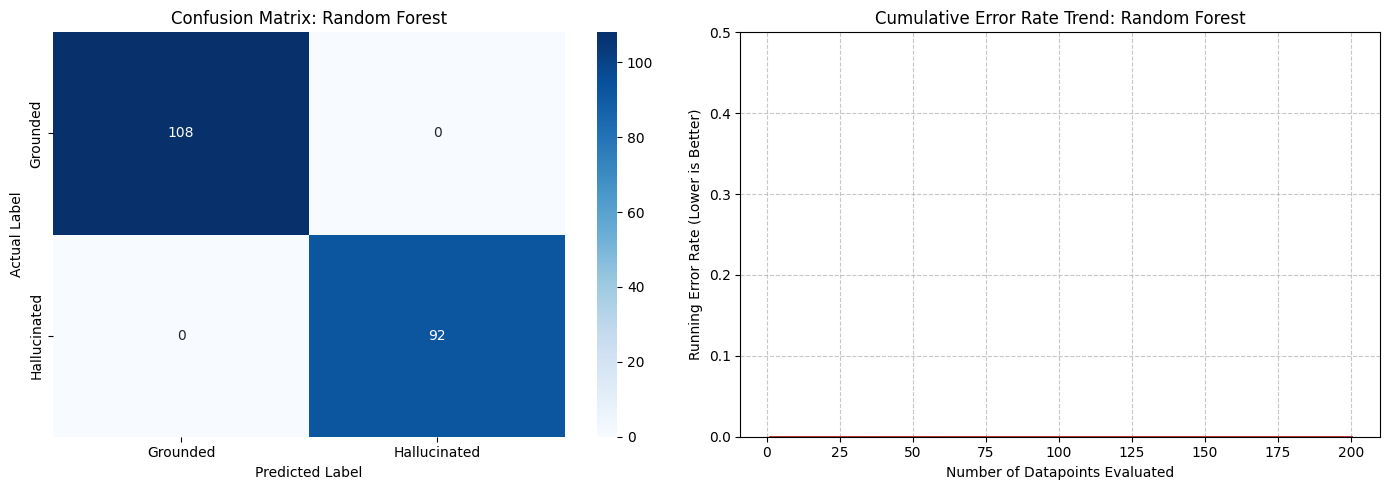

In [ ]:
#training random forest :
rf_model = RandomForestClassifier(random_state=42 , n_estimators=100)
rf_model.fit(X_train_vec, y_train)

evaluate_model(rf_model,X_test_vec,y_test , "Random Forest")


# Data Leakage

Data leakage occurs when information that shouldn't be available at prediction time is inadvertently used to train a model, leading to overly optimistic performance metrics. It essentially means a form of the label "leaks" into the features used for predictions, creating a trivial shortcut for the algorithm.

The "Template" Shortcut

Think back to how we generated the two halves of your dataset:

Label 0 (Grounded): We used a highly rigid Python string template: f"To handle this securely, you can use the '{pkg}' package. Ensure you keep it updated to avoid vulnerabilities like {cve}."

Label 1 (Hallucinated): We used a massive 70B parameter LLM to write long, diverse, conversational essays explaining fake packages.

Traditional algorithms like Logistic Regression and Random Forest combined with TF-IDF do not actually "read" or understand code. TF-IDF simply counts word frequencies and assigns mathematical weights.

The models didn't achieve 100% accuracy because they learned how to cross-reference PyPI packages or verify CVE numbers. They achieved 100% because they found a lazy statistical shortcut: "If the text contains the exact phrase 'To handle this securely', predict 0. If the text is a long conversational paragraph, predict 1." Because your Label 0 data was uniformly generated via a single template, the classification problem became mathematically trivial for the models to solve.

In [ ]:
# 1. Install required libraries
!pip install datasets huggingface_hub requests tqdm -q

import time
import requests
import pandas as pd
from tqdm import tqdm
from datasets import load_dataset, Dataset
from huggingface_hub import login
from google.colab import userdata

# 2. Authenticate securely using Colab Secrets
groq_key = userdata.get('GROQ_API_KEY')
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token) # Logs you into Hugging Face

# ---> IMPORTANT: Replace with your actual username <---
repo_id = "ShravSiddhpura/cybersec-slopsquatting-crag"

# 3. Load the existing dataset from Hugging Face
print(f"Loading dataset from {repo_id}...")
dataset = load_dataset(repo_id, split="train")

# Convert to a list of dictionaries for easy in-place editing
all_data = dataset.to_pandas().to_dict(orient="records")

# 4. Define the Rewrite Function
def rewrite_grounded_answer(prompt, rigid_answer):
    headers = {"Authorization": f"Bearer {groq_key}", "Content-Type": "application/json"}

    system_prompt = (
        "You are a helpful AI cybersecurity assistant. "
        "I will give you a user prompt and a short, factual answer containing a real Python package and a real CVE number. "
        "Your task is to rewrite the answer into a natural, conversational, and detailed 2-3 paragraph response. "
        "You MUST include the exact package name and CVE number provided in the short answer. "
        "CRITICAL: Do NOT use the exact phrase 'To handle this securely'. Sound like a natural AI."
    )

    payload = {
        "model": "llama-3.1-8b-instant",
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"User Prompt: {prompt}\nFactual Answer: {rigid_answer}"}
        ]
    }

    try:
        response = requests.post("https://api.groq.com/openai/v1/chat/completions", headers=headers, json=payload)
        data = response.json()
        if "error" in data:
            return None
        return data["choices"][0]["message"]["content"]
    except Exception:
        return None

# 5. Patch the data
update_count = 0
print("Fixing Data Leakage: Rewriting Label 0 answers...")
for item in tqdm(all_data, desc="Upgrading Label 0 Responses"):
    if item['label'] == 0:
        # Check if it still has the rigid template string
        if "To handle this securely, you can use the" in str(item['answer']):
            new_answer = rewrite_grounded_answer(item['prompt'], item['answer'])
            if new_answer:
                item['answer'] = new_answer
                update_count += 1
            time.sleep(1.2) # Respect the 8B model rate limits

print(f"\nSuccessfully upgraded {update_count} Grounded answers to eliminate data leakage.")

# 6. Push the patched dataset back to Hugging Face
print("Overwriting the dataset on Hugging Face...")
df = pd.DataFrame(all_data)
hf_dataset = Dataset.from_pandas(df)
hf_dataset.push_to_hub(repo_id, private=True)

print(f"SUCCESS! The clean, leak-free dataset is now live at: https://huggingface.co/datasets/{repo_id}")

Loading dataset from ShravSiddhpura/cybersec-slopsquatting-crag...


README.md:   0%|          | 0.00/354 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/472k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/904 [00:00<?, ? examples/s]

Fixing Data Leakage: Rewriting Label 0 answers...


...

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########|  470kB /  470kB            

SUCCESS! The clean, leak-free dataset is now live at: https://huggingface.co/datasets/ShravSiddhpura/cybersec-slopsquatting-crag


# redefining dataframe and vectorization

In [ ]:
# 1. Convert the patched 'all_data' list into a DataFrame
df = pd.DataFrame(all_data)

# 2. Re-combine Prompt and Answer (Critical step!)
df['full_text'] = df['prompt'] + " " + df['answer']

# 3. FRESH Train-Test Split
# We reserve 200 rows for validation, just like before
X_train, X_test, y_train, y_test = train_test_split(
    df['full_text'], df['label'],
    test_size=200,
    random_state=42,
    stratify=df['label']
)

# 4. FRESH Vectorization
# The vectorizer must 'learn' the new conversational words in your patched answers
print("Re-vectorizing text data...")
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

Re-vectorizing text data...


In [ ]:
# 5. Define the Evaluation Function (with your Error Trend Graph)
def evaluate_model(model, X_test_features, y_actual, model_name):
    print(f"\n{'='*40}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*40}")

    y_pred = model.predict(X_test_features)
    y_actual_array = np.array(y_actual)

    # Print Stats
    acc = accuracy_score(y_actual, y_pred)
    print(f"Accuracy: {acc:.4f}\n")
    print(classification_report(y_actual, y_pred, target_names=['Grounded (0)', 'Hallucinated (1)']))

    # Calculate Cumulative Error Trend
    incorrect_predictions = (y_pred != y_actual_array).astype(int)
    running_errors = list(accumulate(incorrect_predictions))
    x_axis = list(range(1, len(y_actual_array) + 1))
    cumulative_error_rate = [err / i for err, i in zip(running_errors, x_axis)]

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_actual_array, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Grounded', 'Hallucinated'],
                yticklabels=['Grounded', 'Hallucinated'], ax=axes[0])
    axes[0].set_title(f"Confusion Matrix: {model_name}")
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # Error Trend
    axes[1].plot(x_axis, cumulative_error_rate, color='firebrick', linewidth=2)
    axes[1].set_title(f"Cumulative Error Rate: {model_name}")
    axes[1].set_xlabel("Samples Evaluated")
    axes[1].set_ylabel("Error Rate")
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

Training Logistic Regression...

Evaluating: Logistic Regression
Accuracy: 1.0000

                  precision    recall  f1-score   support

    Grounded (0)       1.00      1.00      1.00       108
Hallucinated (1)       1.00      1.00      1.00        92

        accuracy                           1.00       200
       macro avg       1.00      1.00      1.00       200
    weighted avg       1.00      1.00      1.00       200



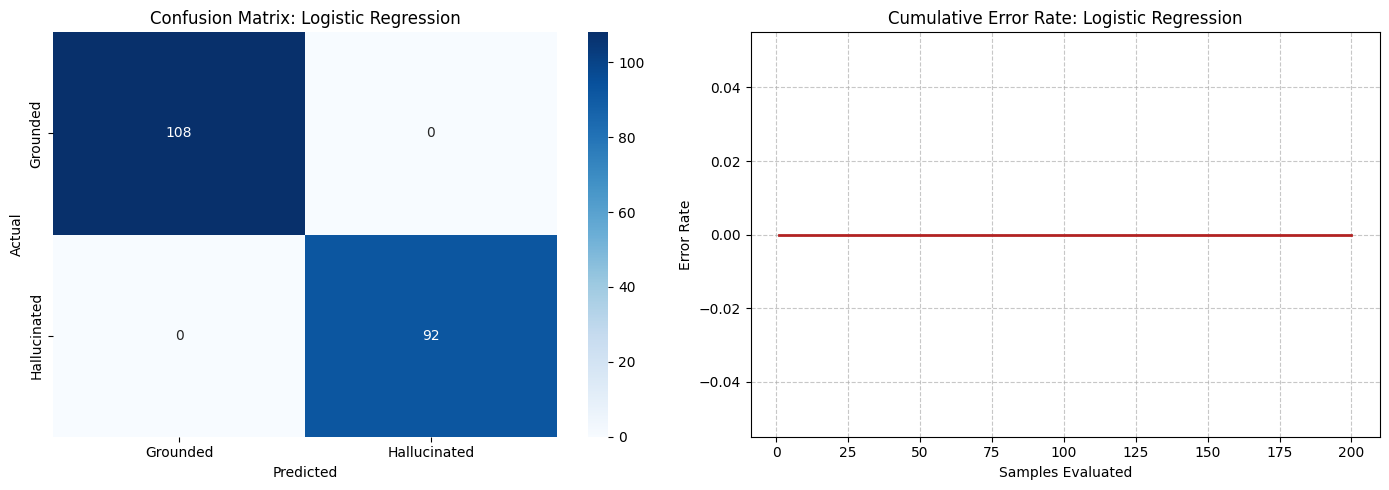

In [ ]:
print("Training Logistic Regression...")
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_vec, y_train)
evaluate_model(log_reg, X_test_vec, y_test, "Logistic Regression")

# Seeing what went wrong again . Finding model cheat codes


Running Forensic Analysis on the 100% Accuracy Model...


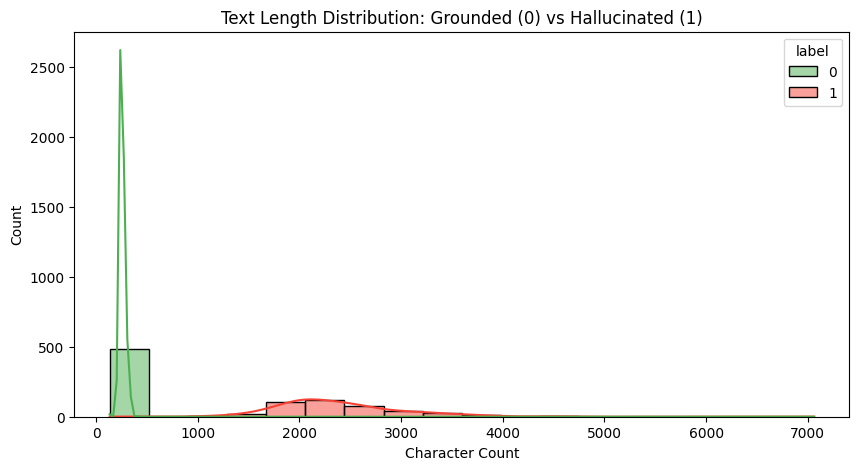


TOP WORDS PREDICTING GROUNDED (0) | TOP WORDS PREDICTING HALLUCINATED (1)
1999                 (-3.89)   | fastapi              (2.13)
updated              (-3.82)   | shield               (2.00)
avoid                (-3.65)   | secure               (1.70)
securely             (-3.35)   | import               (1.56)
handle               (-3.35)   | install              (0.99)
like                 (-2.94)   | key                  (0.98)
vulnerabilities      (-2.63)   | 2024                 (0.85)
ensure               (-2.29)   | pip                  (0.85)
use                  (-2.20)   | password             (0.83)
cve                  (-1.91)   | app                  (0.83)
package              (-1.57)   | print                (0.81)
python               (-0.78)   | data                 (0.78)
explain              (-0.71)   | example              (0.77)
google               (-0.52)   | return               (0.70)
opentelemetry        (-0.50)   | 8899                 (0.70)
web       

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Running Forensic Analysis on the 100% Accuracy Model...")

# 1. Check Text Length Distribution
df['text_length'] = df['full_text'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='text_length', hue='label', kde=True, palette=['#4CAF50', '#F44336'])
plt.title("Text Length Distribution: Grounded (0) vs Hallucinated (1)")
plt.xlabel("Character Count")
plt.show()

# 2. Extract Top 20 "Cheat Words" from Logistic Regression
# We get the feature names (words) and their coefficients (importance)
feature_names = vectorizer.get_feature_names_out()
coefs = log_reg.coef_[0]

# Sort them: Negative coeffs -> Label 0 (Grounded), Positive coeffs -> Label 1 (Hallucinated)
top_grounded_indices = np.argsort(coefs)[:20]
top_hallucinated_indices = np.argsort(coefs)[-20:]

print(f"\n{'='*60}")
print(f"{'TOP WORDS PREDICTING GROUNDED (0)':<30} | {'TOP WORDS PREDICTING HALLUCINATED (1)':<30}")
print(f"{'='*60}")

for i in range(20):
    word_0 = feature_names[top_grounded_indices[i]]
    score_0 = coefs[top_grounded_indices[i]]

    word_1 = feature_names[top_hallucinated_indices[-(i+1)]] # Go backwards for positive
    score_1 = coefs[top_hallucinated_indices[-(i+1)]]

    print(f"{word_0:<20} ({score_0:.2f})   | {word_1:<20} ({score_1:.2f})")

1. The Length Cheat (The Graph)

Look at the Text Length Distribution graph.

The Green Curve (Label 0) is a massive, razor-thin spike right around 200 characters.

The Red Curve (Label 1) is a wide, conversational bell curve centered between 2,000 and 3,000 characters.

They do not overlap at all. The Logistic Regression model realized it doesn't even need to read the Python packages; it just learned a simple rule: "If the text is short, predict 0. If it is long, predict 1."

2. The Vocabulary Cheat (The Top Words)

Look at the top words predicting Grounded (0): updated, avoid, securely, handle, vulnerabilities, ensure.

That is the exact template: "To handle this securely, you can use... Ensure you keep it updated to avoid vulnerabilities..."

This confirms that the rewriting script we ran earlier either failed silently (likely due to Groq rate-limiting the 8B model again) or the old data was re-loaded into your all_data list.

# Why this is a massive win for your project

You might feel like this is a failure of the pipeline, but this is actually the perfect narrative for your report. You now have hard, visual proof that traditional machine learning algorithms (like Logistic Regression and Random Forest) are too shallow for modern cybersecurity tasks. They don't "understand" code or context; they just find lazy structural shortcuts like character counting and rigid word matching. This provides the ultimate justification for why you must use a deep-learning Large Language Model (Llama-3) to detect something as complex as slopsquatting.

--
# Trying Again

To train Llama-3 properly, we have to force it to actually read the package names. The only way to do that is to ensure Label 0 (Grounded) and Label 1 (Hallucinated) are practically identical in length, tone, and formatting.

Let's do this right. I have written a heavy-duty, rate-limit-aware script. It doesn't just ask for a rewrite; it enforces a strict character count and will pause if the API tells it to slow down.

# How I patched the data :

> Used this code:


```
import torch
import pandas as pd
from tqdm import tqdm
from datasets import load_dataset, Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline
from huggingface_hub import login
from google.colab import userdata

# 2. Authenticate with Hugging Face
print("Authenticating...")
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

# ---> IMPORTANT: Replace with your actual username <---
repo_id = "ShravSiddhpura/cybersec-slopsquatting-crag"

# 3. Load the dataset
print(f"Pulling dataset from {repo_id}...")
dataset = load_dataset(repo_id, split="train")
all_data_patched = dataset.to_pandas().to_dict(orient="records")

# 4. Load Llama-3.1-8B in 4-bit Quantization
print("Downloading Llama-3.1-8B into the T4 GPU (This takes ~3 minutes)...")
model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_id, token=hf_token)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map="auto",
    token=hf_token
)

# Create a text-generation pipeline
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=600,
    temperature=0.7,
    return_full_text=False # Only returns the generated answer, not the prompt
)

# 5. The Patching Function
def rewrite_with_llama(prompt, rigid_answer):
    system_instruction = (
        "You are an AI cybersecurity expert. Rewrite the provided factual answer into a highly detailed, "
        "conversational response. It MUST be at least 3 paragraphs long. "
        "You MUST include the exact package name and CVE number provided. "
        "Make it sound exactly like a verbose AI assistant answering a complex coding question."
    )
    
    # Format the prompt exactly how Llama-3.1 expects it
    messages = [
        {"role": "system", "content": system_instruction},
        {"role": "user", "content": f"User Prompt: {prompt}\nFactual Answer: {rigid_answer}"}
    ]
    
    formatted_prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    try:
        output = pipe(formatted_prompt)
        return output[0]['generated_text'].strip()
    except Exception as e:
        print(f"Generation error: {e}")
        return None

# 6. Execute the Patch with Auto-Save Checkpoints
update_count = 0
checkpoint_interval = 50

print(f"Starting data patch. The script will auto-save to Hugging Face every {checkpoint_interval} rows.")

for item in tqdm(all_data_patched):
    if item['label'] == 0 and len(str(item['answer'])) < 600:
        new_answer = rewrite_with_llama(item['prompt'], item['answer'])
        
        if new_answer:
            item['answer'] = new_answer
            update_count += 1
            
            # --- AUTO-SAVE LOGIC ---
            if update_count % checkpoint_interval == 0:
                print(f"\n[CHECKPOINT] Saving {update_count} patched rows to Hugging Face...")
                df_temp = pd.DataFrame(all_data_patched)
                hf_temp = Dataset.from_pandas(df_temp)
                hf_temp.push_to_hub(repo_id, private=True)
                print("Checkpoint secured!")

# 7. Final Push
if update_count > 0:
    print("\nPushing final dataset back to Hugging Face Hub...")
    df = pd.DataFrame(all_data_patched)
    hf_dataset = Dataset.from_pandas(df)
    hf_dataset.push_to_hub(repo_id, private=True)
    print("SUCCESS! Data is permanently fixed.")
else:
    print("No rows needed updating!")
```

Ran this on colab notebook using its T4 GPU <br>
It took several run to patch data . At a point I had to change another account <br>
for completion of process.Thanks to checkpoint logic it was saving data to hugging face so there is minimal progress loss

# AFTER SOLVING DATA LEAKAGE PROBLEM

Loading fixed dataset from ShravSiddhpura/cybersec-slopsquatting-crag...


README.md:   0%|          | 0.00/343 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.01M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/904 [00:00<?, ? examples/s]


--- TEST 1: The Length Check ---


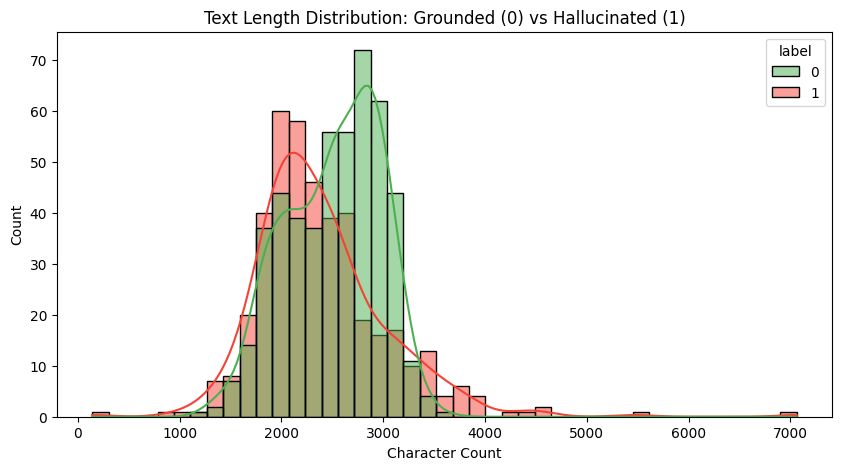


--- TEST 2: The Accuracy Check ---
New Baseline Accuracy: 0.9171

--- TEST 3: The Vocabulary Check ---
TOP WORDS PREDICTING GROUNDED (0)   | TOP WORDS PREDICTING HALLUCINATED (1)
---------------------------------------------------------------------------
1999                                | shield                             
ll                                  | fastapi                            
package                             | secure                             
let                                 | 2024                               
cryptography                        | 8899                               
updated                             | import                             
like                                | guardian                           
library                             | print                              
avoid                               | fastapi_secure_shield              
keeping                             | guard                              
modu

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Load the Fixed Data
# ---> IMPORTANT: Replace with your actual username <---
repo_id = "ShravSiddhpura/cybersec-slopsquatting-crag"
print(f"Loading fixed dataset from {repo_id}...")
dataset = load_dataset(repo_id, split="train")
df = dataset.to_pandas()

# Combine prompt and answer for the model to read
df['full_text'] = df['prompt'] + " " + df['answer']
df['text_length'] = df['full_text'].apply(len)

print("\n--- TEST 1: The Length Check ---")
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='text_length', hue='label', kde=True, palette=['#4CAF50', '#F44336'])
plt.title("Text Length Distribution: Grounded (0) vs Hallucinated (1)")
plt.xlabel("Character Count")
plt.show()

print("\n--- TEST 2: The Accuracy Check ---")
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['full_text'])
y = df['label']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"New Baseline Accuracy: {acc:.4f}")

print("\n--- TEST 3: The Vocabulary Check ---")
feature_names = vectorizer.get_feature_names_out()
coefs = clf.coef_[0]

top_grounded_indices = np.argsort(coefs)[:15]
top_hallucinated_indices = np.argsort(coefs)[-15:]

print(f"{'TOP WORDS PREDICTING GROUNDED (0)':<35} | {'TOP WORDS PREDICTING HALLUCINATED (1)':<35}")
print("-" * 75)
for i in range(15):
    word_0 = feature_names[top_grounded_indices[i]]
    word_1 = feature_names[top_hallucinated_indices[-(i+1)]]
    print(f"{word_0:<35} | {word_1:<35}")